In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt


In [2]:
base_convenios=pd.read_csv('/content/data_tax_treaty.csv')
base_convenios.head()

,Country A,Country B,Type,Date of signature,Effective,Status,Source,WHTrates,PE,Other,...,12(2)E,12(A),13(4),13(5),14,16(2),21(3),25B(5),27,29
0,Albania,Israel,Original,2021,2022.0,In Force,0.30,0.31,0.45,0.13,...,5,0,YES,NO,NO,NO,NO,NO,NO,PPT
1,Albania,Turkey,Original,1994,1997.0,In Force,0.19,0.38,0.06,0.13,...,10,0,NO,NO,YES,NO,NO,NO,NO,NaN
2,Albania,Romania,Original,1994,1995.0,In Force,0.47,0.47,0.58,0.38,...,15,0,NO,NO,YES,NO,YES,NO,NO,NaN
3,Albania,Italy,Original,1994,2000.0,In Force,0.19,0.25,0.19,0.13,...,5,0,NO,NO,YES,NO,NO,NO,NO,NaN
4,Albania,Russia,Original,1995,1998.0,In Force,0.23,0.38,0.06,0.25,...,10,0,NO,NO,YES,NO,YES,NO,NO,NaN


In [8]:
base_convenios.columns

Index(['Country A', 'Country B', 'Type', 'Date of signature', 'Effective',
       'Status', 'Source', 'WHTrates', 'PE', 'Other', 'UN', '5(3)(a)C',
       '5(3)(a)S', '5(3)(b)', '5(4)(a)', '5(4)(b)', '5(5)(b)', '5(6)', '5(7)',
       '7(1)(b&c)', '7(3)', '8(2)', '10(2)(a)Q', '10(2)(a)T', '10(2)(b)',
       '11(2)', '11(2)F', '12(2)', '12(2)C', '12(2)E', '12(A)', '13(4)',
       '13(5)', '14', '16(2)', '21(3)', '25B(5)', '27', '29'],
      dtype='object')

In [21]:
G = nx.from_pandas_edgelist(base_convenios,
                            source='Country A',
                            target='Country B',
                            edge_attr='Date of signature')

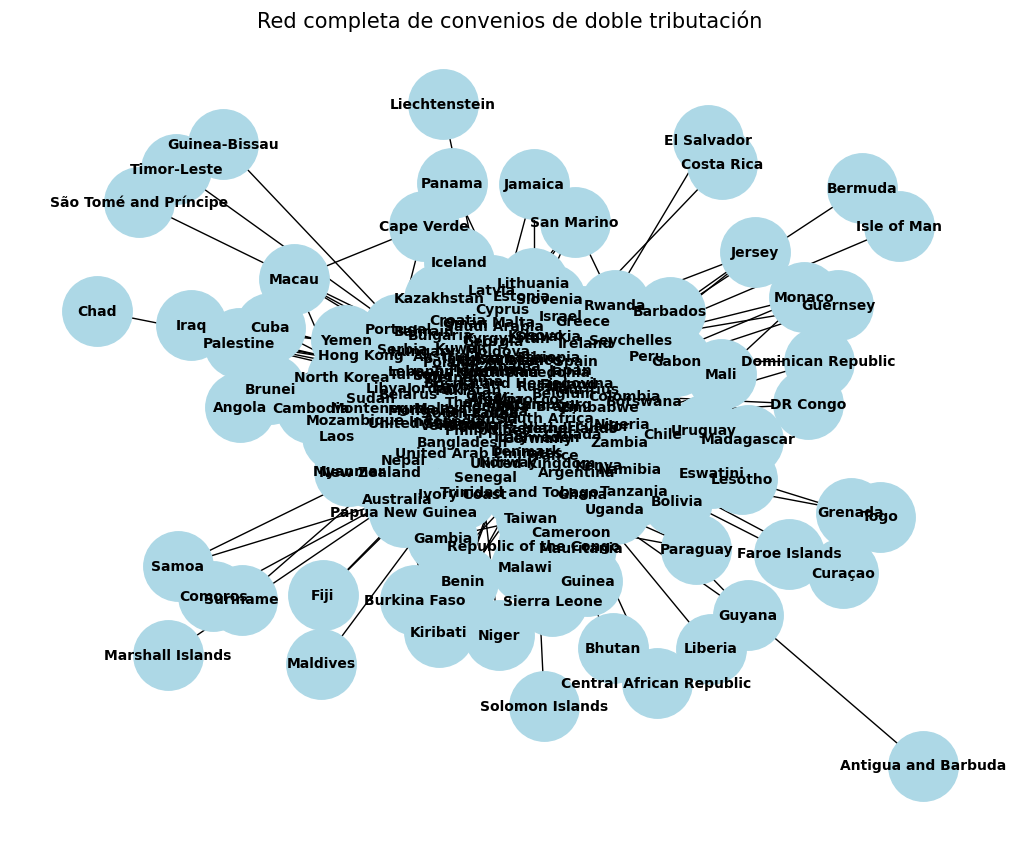

In [22]:
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2500, font_size=10, font_weight='bold')
plt.title("Red completa de convenios de doble tributación", size=15)
plt.show()

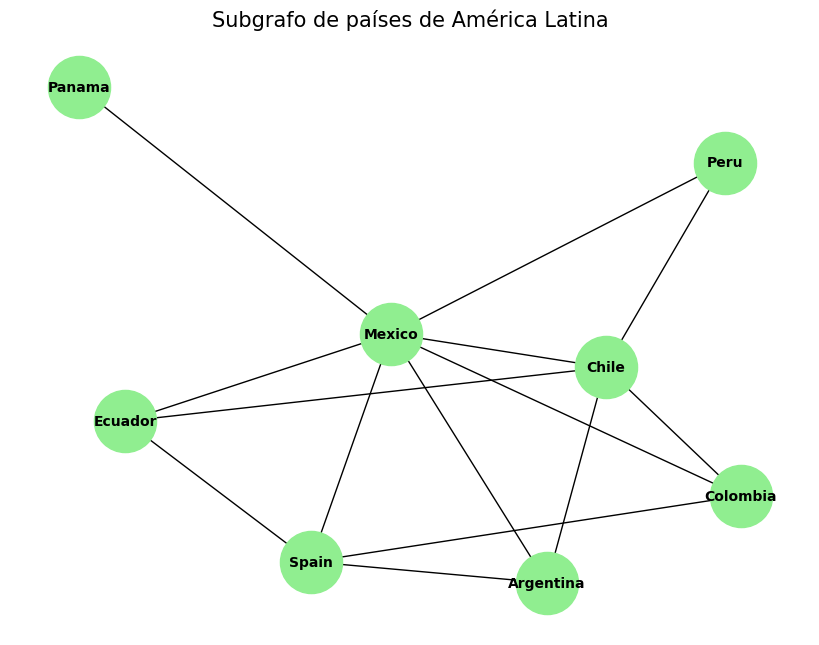

In [26]:
# Lista de nodos para el subgrafo
paises_subgrafo = ['Mexico', 'Chile', 'Colombia', 'Ecuador', 'Peru', 'Panama', 'Argentina', 'Spain']

# Crear el subgrafo
subgrafo = G.subgraph(paises_subgrafo)

# Dibujar el subgrafo
plt.figure(figsize=(8, 6))
pos_sub = nx.spring_layout(subgrafo, pos=pos)
nx.draw(subgrafo, pos_sub, with_labels=True, node_color='lightgreen', node_size=2000, font_size=10, font_weight='bold')
plt.title("Subgrafo de países de América Latina", size=15)
plt.show()

In [27]:
# Obtener una lista de todos los años únicos de las aristas
anios = [int(d['Date of signature']) for u, v, d in G.edges(data=True)]

# Crear una paleta de colores (colormap)
# Puedes elegir cualquier mapa de colores de Matplotlib, como 'viridis', 'plasma', 'cividis', etc.
cmap = cm.get_cmap('plasma')

# Normalizar los años para que se ajusten al rango del colormap (0 a 1)
min_anio = min(anios)
max_anio = max(anios)
norm = plt.Normalize(vmin=min_anio, vmax=max_anio)
colores_aristas = [cmap(norm(anio)) for anio in anios]

/tmp/ipython-input-1542449225.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('plasma')


ValueError: Unable to determine Axes to steal space for Colorbar. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.

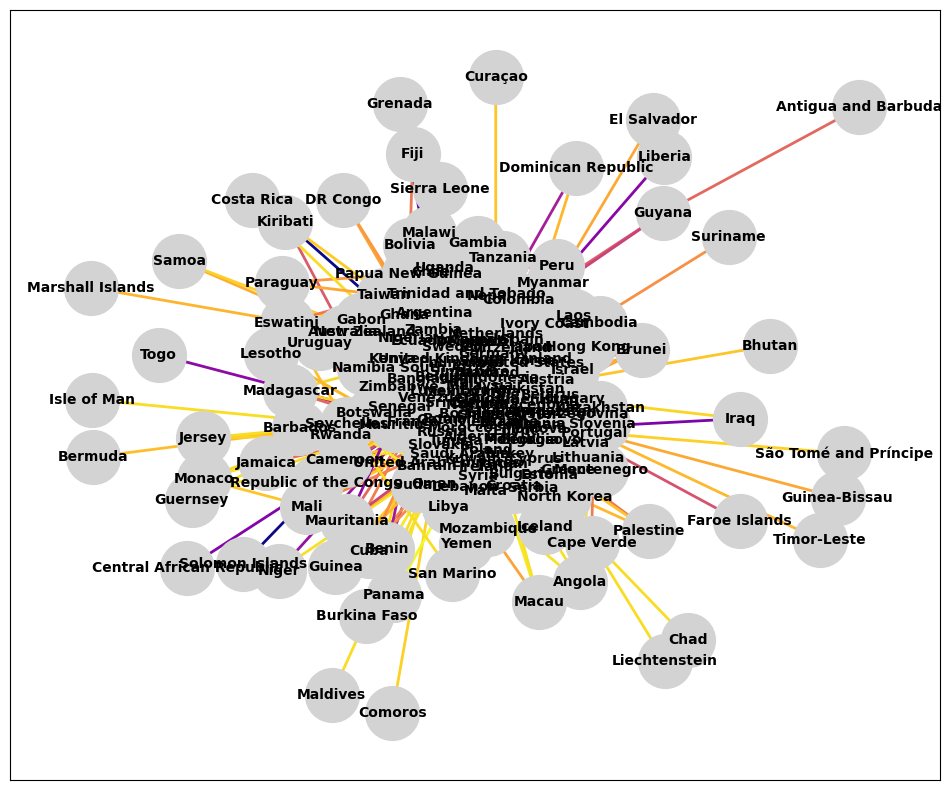

In [28]:
plt.figure(figsize=(12, 10))

# Definir la posición de los nodos
pos = nx.spring_layout(G)

# Dibujar los nodos y sus etiquetas
nx.draw_networkx_nodes(G, pos, node_color='lightgray', node_size=1500)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

# Dibujar las aristas con los colores asignados
# Es crucial que el orden de edge_color coincida con el de la lista G.edges()
aristas_sorted = list(G.edges(data=True))
colores_aristas_sorted = [cmap(norm(int(d['Date of signature']))) for u, v, d in aristas_sorted]
nx.draw_networkx_edges(G, pos, edgelist=aristas_sorted, edge_color=colores_aristas_sorted, width=2)

# Crear la barra de color
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([]) # Necesario para que funcione el colorbar
cbar = plt.colorbar(sm, orientation='vertical', shrink=0.7)
cbar.set_label('Año de la firma del convenio')

plt.title("Red de convenios por año de firma", size=15)
plt.axis('off')
plt.show()

In [4]:
pip install pyvis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 43.6 MB/s eta 0:00:00


In [6]:
#Generado con Gemini

import pandas as pd
import networkx as nx
from pyvis.network import Network



G_nx = nx.from_pandas_edgelist(base_convenios,
                               'Country A',
                               'Country B',
                               edge_attr='Date of signature')

# 3. Convertir el grafo de NetworkX a un objeto de Pyvis
# La función from_nx() es la forma más sencilla de hacerlo.
# También puedes especificar la altura y el ancho del lienzo[cite: 3].
nt = Network(height="750px", width="100%", bgcolor="#222222", font_color="white")
nt.from_nx(G_nx)

# Opcional: Añadir un título a las aristas para que muestren el año de firma
# Esto aparecerá en un pop-up al pasar el mouse sobre la arista
for edge in nt.edges:
    edge['title'] = f"Año de firma: {edge['Date of signature']}"

# Opcional: Agregar interactividad. Esto mostrará botones para modificar el grafo.
# Los botones te permiten ajustar la física, el diseño y otras opciones.
nt.show_buttons(filter_=['physics', 'layout', 'edges']) #[cite: 261, 266]

# 4. Generar el archivo HTML y mostrarlo
# El archivo 'network_interactiva.html' se guardará en tu directorio de trabajo.
nt.save_graph("network_interactiva.html")
print("Archivo 'network_interactiva.html' creado. ¡Ábrelo en tu navegador para ver la red!")

Archivo 'network_interactiva.html' creado. ¡Ábrelo en tu navegador para ver la red!
